In [20]:
import os
import numpy as np
import pandas as pd
import SimpleITK as sitk
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, kruskal
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
#setup and load extracted features 

In [3]:
# Load your existing feature CSV
csv_path = r"C:\Users\ardra nirwan\radiomics_features.csv"
df = pd.read_csv(csv_path)

# Fix: Rename Idm to InverseDifferenceMoment to match task requirements
if 'original_glcm_Idm' in df.columns:
    df = df.rename(columns={'original_glcm_Idm': 'original_glcm_InverseDifferenceMoment'})

print(f"Loaded {len(df)} patients with {len(df.columns)} features")
print("Patients:", list(df['patient']))

Loaded 29 patients with 130 features
Patients: ['100_series0', '101_series0', '102_series0', '103_series0', '104_series0', '105_series0', '106_series0', '107_series0', '108_series0', '109_series0', '10_series0', '110_series0', '111_series0', '112_series0', '113_series0', '114_series0', '115_series0', '116_series0', '117_series0', '118_series0', '119_series0', '120_series0', '121_series0', '122_series0', '123_series0', '124_series0', '125_series0', '126_series0', '127_series0']


In [4]:
#agatson score calculation 

In [5]:
def compute_agatston(nifti_path):
    """
    Compute Agatston score from a NIfTI CT image using original spacing.
    Standard clinical method: threshold 130 HU, density weighting per lesion.
    """
    image = sitk.ReadImage(nifti_path)
    spacing = image.GetSpacing()  # (x_mm, y_mm, z_mm)
    pixel_area = spacing[0] * spacing[1]  # mm² per voxel in-plane

    img_array = sitk.GetArrayFromImage(image)  # shape: (z, y, x)

    agatston_total = 0.0

    # Process slice by slice (standard Agatston is 2D per slice)
    for z in range(img_array.shape[0]):
        slice_hu = img_array[z]

        # Threshold at 130 HU
        calcium_mask = (slice_hu >= 130).astype(np.uint8)

        if calcium_mask.sum() == 0:
            continue

        # Connected component labeling on this 2D slice
        calcium_sitk = sitk.GetImageFromArray(calcium_mask)
        cc = sitk.ConnectedComponent(calcium_sitk)
        cc_array = sitk.GetArrayFromImage(cc)

        num_labels = cc_array.max()

        for label_id in range(1, num_labels + 1):
            lesion_mask = (cc_array == label_id)

            # Skip tiny lesions < 1 mm² (noise filter)
            lesion_area_mm2 = lesion_mask.sum() * pixel_area
            if lesion_area_mm2 < 1.0:
                continue

            # Peak HU in this lesion
            peak_hu = slice_hu[lesion_mask].max()

            # Density multiplier (Agatston 1990)
            if peak_hu >= 400:
                density = 4
            elif peak_hu >= 300:
                density = 3
            elif peak_hu >= 200:
                density = 2
            else:  # 130-199
                density = 1

            agatston_total += lesion_area_mm2 * density

    return round(agatston_total, 2)


def categorize_agatston(score):
    """Categorize Agatston score into clinical risk groups."""
    if score == 0:
        return 'No calcium (0)'
    elif score < 100:
        return 'Mild (1-99)'
    elif score < 400:
        return 'Moderate (100-399)'
    else:
        return 'Severe (≥400)'


print("Agatston functions defined. Ready to compute scores.")

Agatston functions defined. Ready to compute scores.


In [6]:
# Compute Agatston scores for all patients in my CSV
nifti_dir = r"C:\Users\ardra nirwan\COCA_nifti"

agatston_scores = []

for patient_id in df['patient']:
    # Match patient ID to NIfTI file
    # patient column looks like '100_series0', file looks like '100_series0.nii.gz'
    nifti_path = os.path.join(nifti_dir, patient_id + '.nii.gz')
    
    # Fallback: try .nii extension
    if not os.path.exists(nifti_path):
        nifti_path = os.path.join(nifti_dir, patient_id + '.nii')

    if not os.path.exists(nifti_path):
        print(f"  File not found for {patient_id}, skipping...")
        agatston_scores.append(np.nan)
        continue

    try:
        score = compute_agatston(nifti_path)
        agatston_scores.append(score)
        print(f"  {patient_id}: Agatston = {score}")
    except Exception as e:
        print(f"  Error for {patient_id}: {e}")
        agatston_scores.append(np.nan)

# Add to dataframe
df['agatston_score'] = agatston_scores
df['agatston_category'] = df['agatston_score'].apply(
    lambda x: categorize_agatston(x) if not np.isnan(x) else 'Unknown'
)

print(f"\nDone! Computed scores for {df['agatston_score'].notna().sum()} patients")
print("\nAgatston category distribution:")
print(df['agatston_category'].value_counts())

  100_series0: Agatston = 622807.43
  101_series0: Agatston = 858516.31
  102_series0: Agatston = 1207971.4
  103_series0: Agatston = 1067185.38
  104_series0: Agatston = 551572.72
  105_series0: Agatston = 1267813.88
  106_series0: Agatston = 1498104.79
  107_series0: Agatston = 843418.69
  108_series0: Agatston = 1090878.23
  109_series0: Agatston = 1457087.4
  10_series0: Agatston = 3301125.53
  110_series0: Agatston = 783648.85
  111_series0: Agatston = 1752585.76
  112_series0: Agatston = 967745.39
  113_series0: Agatston = 824248.4
  114_series0: Agatston = 1158393.66
  115_series0: Agatston = 1455880.78
  116_series0: Agatston = 761649.51
  117_series0: Agatston = 1210185.22
  118_series0: Agatston = 873512.77
  119_series0: Agatston = 621122.22
  120_series0: Agatston = 665297.53
  121_series0: Agatston = 898382.52
  122_series0: Agatston = 1459235.41
  123_series0: Agatston = 1638601.38
  124_series0: Agatston = 787360.63
  125_series0: Agatston = 1335210.71
  126_series0: Aga

In [7]:
import os
import numpy as np
import pandas as pd
import SimpleITK as sitk

# ----------------------------------------------------------------
# FIXED Agatston Score — reads from COCA_nifti (original HU)
# Uses the HEART MASK to restrict region, then finds calcium WITHIN it
# ----------------------------------------------------------------

def compute_agatston_fixed(image_path, mask_path):
    """
    Correct Agatston score calculation:
    1. Load CT image (original HU values)
    2. Load heart mask (to restrict to cardiac region)
    3. Apply 130 HU threshold WITHIN the heart mask
    4. Connected component analysis per slice
    5. Density weighting and area summation
    """
    # Load image and mask
    image = sitk.ReadImage(image_path)
    mask  = sitk.ReadImage(mask_path)

    # Resample mask to image space if sizes differ
    if image.GetSize() != mask.GetSize():
        resampler = sitk.ResampleImageFilter()
        resampler.SetReferenceImage(image)
        resampler.SetInterpolator(sitk.sitkNearestNeighbor)
        resampler.SetDefaultPixelValue(0)
        mask = resampler.Execute(mask)

    spacing      = image.GetSpacing()   # (x_mm, y_mm, z_mm)
    pixel_area   = spacing[0] * spacing[1]  # mm² per in-plane voxel

    img_array  = sitk.GetArrayFromImage(image)   # shape: (z, y, x)
    mask_array = sitk.GetArrayFromImage(mask)    # binary: 1 = heart

    # Restrict to heart region only
    cardiac_hu = np.where(mask_array > 0, img_array, -1000)

    agatston_total = 0.0

    for z in range(cardiac_hu.shape[0]):
        slice_hu = cardiac_hu[z]

        # Standard calcium threshold: >= 130 HU
        calcium_mask = (slice_hu >= 130).astype(np.uint8)

        if calcium_mask.sum() == 0:
            continue

        # Connected components on this 2D slice
        cc_sitk  = sitk.ConnectedComponent(sitk.GetImageFromArray(calcium_mask))
        cc_array = sitk.GetArrayFromImage(cc_sitk)
        num_labels = int(cc_array.max())

        for label_id in range(1, num_labels + 1):
            lesion_mask = (cc_array == label_id)

            # Minimum lesion size: 1 mm² (filter noise)
            lesion_area_mm2 = lesion_mask.sum() * pixel_area
            if lesion_area_mm2 < 1.0:
                continue

            # Peak HU in this lesion → density multiplier
            peak_hu = slice_hu[lesion_mask].max()

            if peak_hu >= 400:
                density = 4
            elif peak_hu >= 300:
                density = 3
            elif peak_hu >= 200:
                density = 2
            else:  # 130–199 HU
                density = 1

            agatston_total += lesion_area_mm2 * density

    return round(agatston_total, 2)


def categorize_agatston(score):
    if score == 0:
        return 'No calcium (0)'
    elif score < 100:
        return 'Mild (1-99)'
    elif score < 400:
        return 'Moderate (100-399)'
    else:
        return 'Severe (>=400)'


# ----------------------------------------------------------------
# Run on your patients
# ----------------------------------------------------------------
image_dir = r"C:\Users\ardra nirwan\COCA_nifti"   # ORIGINAL HU NIfTI files
mask_dir  = r"C:\Users\ardra nirwan\COCA_output"  # TotalSegmentator heart masks
csv_path  = r"C:\Users\ardra nirwan\radiomics_features.csv"

df = pd.read_csv(csv_path)

# Fix column name
if 'original_glcm_Idm' in df.columns:
    df = df.rename(columns={'original_glcm_Idm': 'original_glcm_InverseDifferenceMoment'})

agatston_scores = []

for patient_id in df['patient']:
    # Image: COCA_nifti/100_series0.nii.gz
    image_path = os.path.join(image_dir, patient_id + '.nii.gz')
    if not os.path.exists(image_path):
        image_path = os.path.join(image_dir, patient_id + '.nii')

    # Mask: COCA_output/100_series0/heart.nii.gz
    mask_path = os.path.join(mask_dir, patient_id, 'heart.nii.gz')

    if not os.path.exists(image_path):
        print(f"  Image not found: {patient_id}")
        agatston_scores.append(np.nan)
        continue

    if not os.path.exists(mask_path):
        print(f"  Mask not found: {patient_id}")
        agatston_scores.append(np.nan)
        continue

    try:
        score = compute_agatston_fixed(image_path, mask_path)
        agatston_scores.append(score)
        print(f"  {patient_id}: Agatston = {score}  [{categorize_agatston(score)}]")
    except Exception as e:
        print(f"  Error in {patient_id}: {e}")
        agatston_scores.append(np.nan)

df['agatston_score']    = agatston_scores
df['agatston_category'] = df['agatston_score'].apply(
    lambda x: categorize_agatston(x) if pd.notna(x) else 'Unknown'
)

output_csv = r"C:\Users\ardra nirwan\radiomics_features_final.csv"
df.to_csv(output_csv, index=False)

print("\n=== DONE ===")
print(f"Saved: {output_csv}")
print("\nAgatston distribution:")
print(df['agatston_category'].value_counts())
print("\nScore summary:")
print(df['agatston_score'].describe().round(2))

  100_series0: Agatston = 0.0  [No calcium (0)]
  101_series0: Agatston = 0.0  [No calcium (0)]
  102_series0: Agatston = 0.0  [No calcium (0)]
  103_series0: Agatston = 4.51  [Mild (1-99)]
  104_series0: Agatston = 3.78  [Mild (1-99)]
  105_series0: Agatston = 0.0  [No calcium (0)]
  106_series0: Agatston = 0.0  [No calcium (0)]
  107_series0: Agatston = 0.0  [No calcium (0)]
  108_series0: Agatston = 0.0  [No calcium (0)]
  109_series0: Agatston = 0.0  [No calcium (0)]
  10_series0: Agatston = 495.91  [Severe (>=400)]
  110_series0: Agatston = 0.0  [No calcium (0)]
  111_series0: Agatston = 0.0  [No calcium (0)]
  112_series0: Agatston = 0.0  [No calcium (0)]
  113_series0: Agatston = 0.0  [No calcium (0)]
  114_series0: Agatston = 14.64  [Mild (1-99)]
  115_series0: Agatston = 0.0  [No calcium (0)]
  116_series0: Agatston = 0.0  [No calcium (0)]
  117_series0: Agatston = 0.0  [No calcium (0)]
  118_series0: Agatston = 12.5  [Mild (1-99)]
  119_series0: Agatston = 0.0  [No calcium (0

In [8]:
# ----------------------------------------------------------------
# Load final CSV
# ----------------------------------------------------------------
csv_path = r"C:\Users\ardra nirwan\radiomics_features_final.csv"
df = pd.read_csv(csv_path)

print(f"Loaded {len(df)} patients")
print("\nAgatston distribution:")
print(df['agatston_category'].value_counts())

# Required features as per task
required_features = [
    'original_shape_Sphericity',
    'original_shape_SurfaceVolumeRatio',
    'original_shape_Maximum3DDiameter',
    'original_glcm_Contrast',
    'original_glcm_Correlation',
    'original_glcm_InverseDifferenceMoment',
    'original_glszm_SmallAreaEmphasis',
    'original_glszm_LargeAreaEmphasis',
    'original_glszm_ZonePercentage',
    'original_glrlm_ShortRunEmphasis',
    'original_glrlm_LongRunEmphasis',
    'original_glrlm_RunPercentage',
]

# Only keep features that exist
required_features = [f for f in required_features if f in df.columns]
df_valid = df.dropna(subset=['agatston_score']).copy()

print(f"\nUsing {len(required_features)} features for analysis")
print(f"Valid patients (with Agatston score): {len(df_valid)}")


Loaded 29 patients

Agatston distribution:
agatston_category
No calcium (0)        20
Mild (1-99)            7
Severe (>=400)         1
Moderate (100-399)     1
Name: count, dtype: int64

Using 12 features for analysis
Valid patients (with Agatston score): 29


In [9]:

# ----------------------------------------------------------------
# DATASET STATISTICS
# ----------------------------------------------------------------
print("\n" + "="*60)
print("DATASET STATISTICS")
print("="*60)
print(f"\nTotal patients: {len(df_valid)}")
print(f"\nAgatston Score Summary:")
print(df_valid['agatston_score'].describe().round(2))
print(f"\nCategory Breakdown:")
print(df_valid['agatston_category'].value_counts())
print(f"\nRequired Feature Summary:")
print(df_valid[required_features].describe().round(4))



DATASET STATISTICS

Total patients: 29

Agatston Score Summary:
count     29.00
mean      32.59
std      103.84
min        0.00
25%        0.00
50%        0.00
75%        4.51
max      495.91
Name: agatston_score, dtype: float64

Category Breakdown:
agatston_category
No calcium (0)        20
Mild (1-99)            7
Severe (>=400)         1
Moderate (100-399)     1
Name: count, dtype: int64

Required Feature Summary:
       original_shape_Sphericity  original_shape_SurfaceVolumeRatio  \
count                    29.0000                            29.0000   
mean                      0.4621                             0.1331   
std                       0.0226                             0.0155   
min                       0.3723                             0.1057   
25%                       0.4592                             0.1252   
50%                       0.4661                             0.1316   
75%                       0.4748                             0.1419   
max       

In [10]:

# ----------------------------------------------------------------
# SPEARMAN CORRELATION
# ----------------------------------------------------------------
print("\n" + "="*60)
print("SPEARMAN CORRELATION — Features vs Agatston Score")
print("="*60)

spearman_results = []
for feature in required_features:
    corr, pval = spearmanr(df_valid[feature], df_valid['agatston_score'])
    spearman_results.append({
        'Feature': feature.replace('original_', ''),
        'Spearman_r': round(corr, 4),
        'p_value': round(pval, 4),
        'Significant': 'YES ***' if pval < 0.05 else 'no'
    })

spearman_df = pd.DataFrame(spearman_results).sort_values('p_value')
print(spearman_df.to_string(index=False))
print(f"\nSignificant (p<0.05): {len(spearman_df[spearman_df['p_value']<0.05])} / {len(spearman_df)}")


SPEARMAN CORRELATION — Features vs Agatston Score
                     Feature  Spearman_r  p_value Significant
               glcm_Contrast      0.3740   0.0457     YES ***
         glrlm_RunPercentage      0.2784   0.1436          no
glcm_InverseDifferenceMoment     -0.2757   0.1477          no
       glrlm_LongRunEmphasis     -0.2526   0.1861          no
      glrlm_ShortRunEmphasis      0.2514   0.1883          no
        glszm_ZonePercentage      0.2217   0.2478          no
     shape_Maximum3DDiameter      0.2130   0.2674          no
            shape_Sphericity     -0.1748   0.3644          no
     glszm_LargeAreaEmphasis     -0.0838   0.6656          no
    shape_SurfaceVolumeRatio     -0.0697   0.7194          no
     glszm_SmallAreaEmphasis      0.0580   0.7652          no
            glcm_Correlation     -0.0177   0.9273          no

Significant (p<0.05): 1 / 12


In [11]:
# ----------------------------------------------------------------
# KRUSKAL-WALLIS TEST
# ----------------------------------------------------------------
print("\n" + "="*60)
print("KRUSKAL-WALLIS TEST — Features across Agatston Categories")
print("="*60)

categories = df_valid['agatston_category'].unique()
kw_results = []

for feature in required_features:
    groups = [
        df_valid[df_valid['agatston_category'] == cat][feature].dropna().values
        for cat in categories
    ]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) < 2:
        continue
    try:
        stat, pval = kruskal(*groups)
        kw_results.append({
            'Feature': feature.replace('original_', ''),
            'H_statistic': round(stat, 4),
            'p_value': round(pval, 4),
            'Significant': 'YES ***' if pval < 0.05 else 'no'
        })
    except Exception as e:
        pass

kw_df = pd.DataFrame(kw_results).sort_values('p_value')
print(kw_df.to_string(index=False))
print(f"\nSignificant (p<0.05): {len(kw_df[kw_df['p_value']<0.05])} / {len(kw_df)}")



KRUSKAL-WALLIS TEST — Features across Agatston Categories
                     Feature  H_statistic  p_value Significant
               glcm_Contrast       7.2082   0.0656          no
            shape_Sphericity       5.3044   0.1508          no
        glszm_ZonePercentage       5.1559   0.1607          no
            glcm_Correlation       4.9020   0.1791          no
     glszm_SmallAreaEmphasis       4.6860   0.1963          no
glcm_InverseDifferenceMoment       3.9074   0.2716          no
         glrlm_RunPercentage       3.6913   0.2968          no
      glrlm_ShortRunEmphasis       3.5502   0.3143          no
       glrlm_LongRunEmphasis       3.5037   0.3203          no
     glszm_LargeAreaEmphasis       3.4131   0.3322          no
     shape_Maximum3DDiameter       2.6833   0.4431          no
    shape_SurfaceVolumeRatio       2.5170   0.4722          no

Significant (p<0.05): 0 / 12


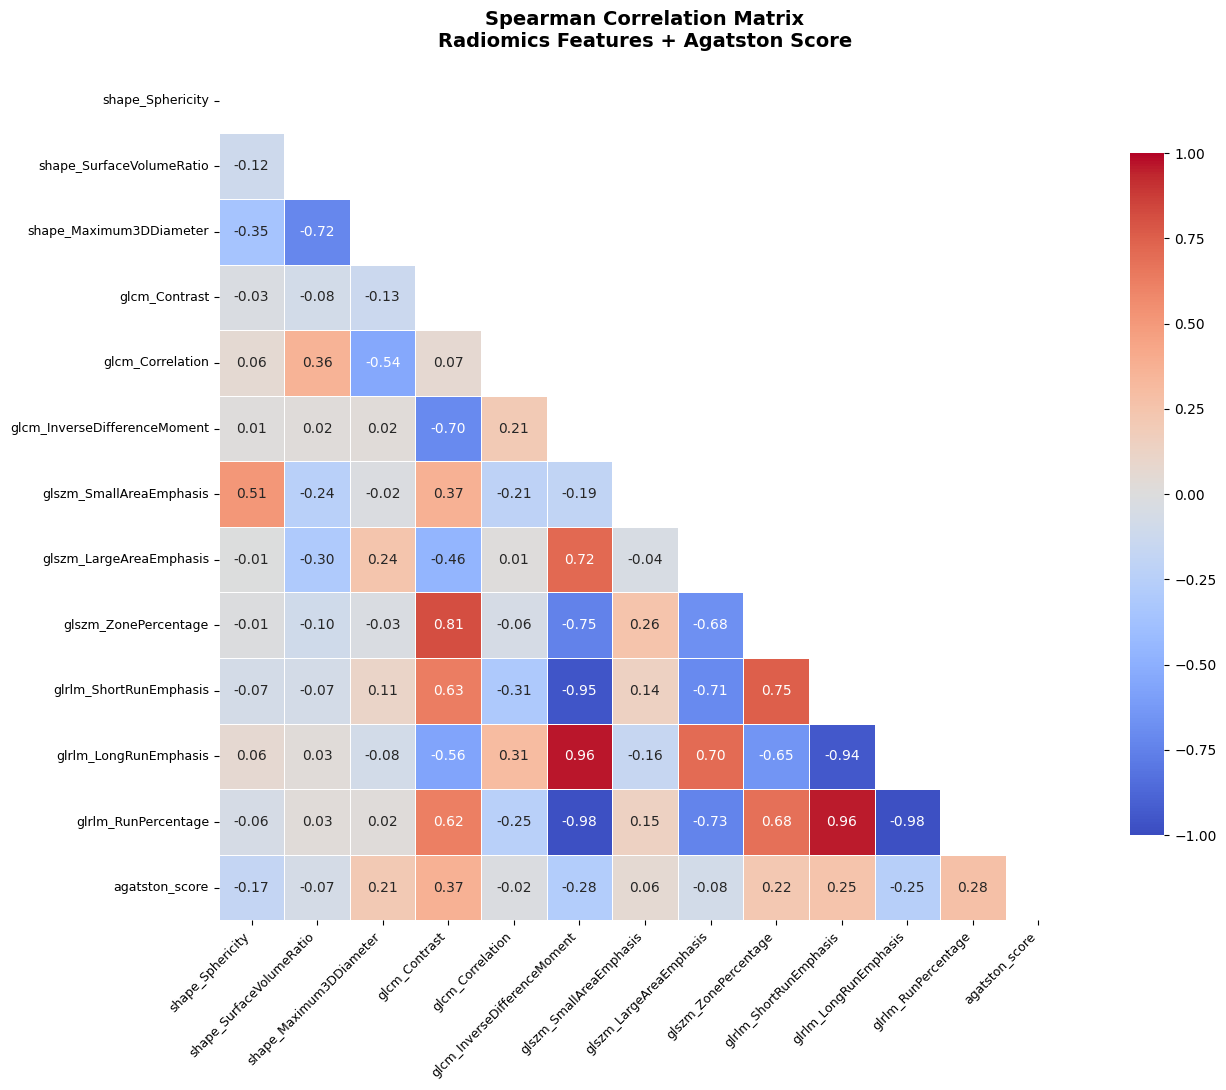

Saved: correlation_matrix.png


In [12]:

features_for_corr = required_features + ['agatston_score']
corr_data = df_valid[features_for_corr].copy()
corr_data.columns = [
    c.replace('original_shape_', 'shape_')
     .replace('original_glcm_', 'glcm_')
     .replace('original_glszm_', 'glszm_')
     .replace('original_glrlm_', 'glrlm_')
    for c in corr_data.columns
]

corr_matrix = corr_data.corr(method='spearman')

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Spearman Correlation Matrix\nRadiomics Features + Agatston Score',
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: correlation_matrix.png")


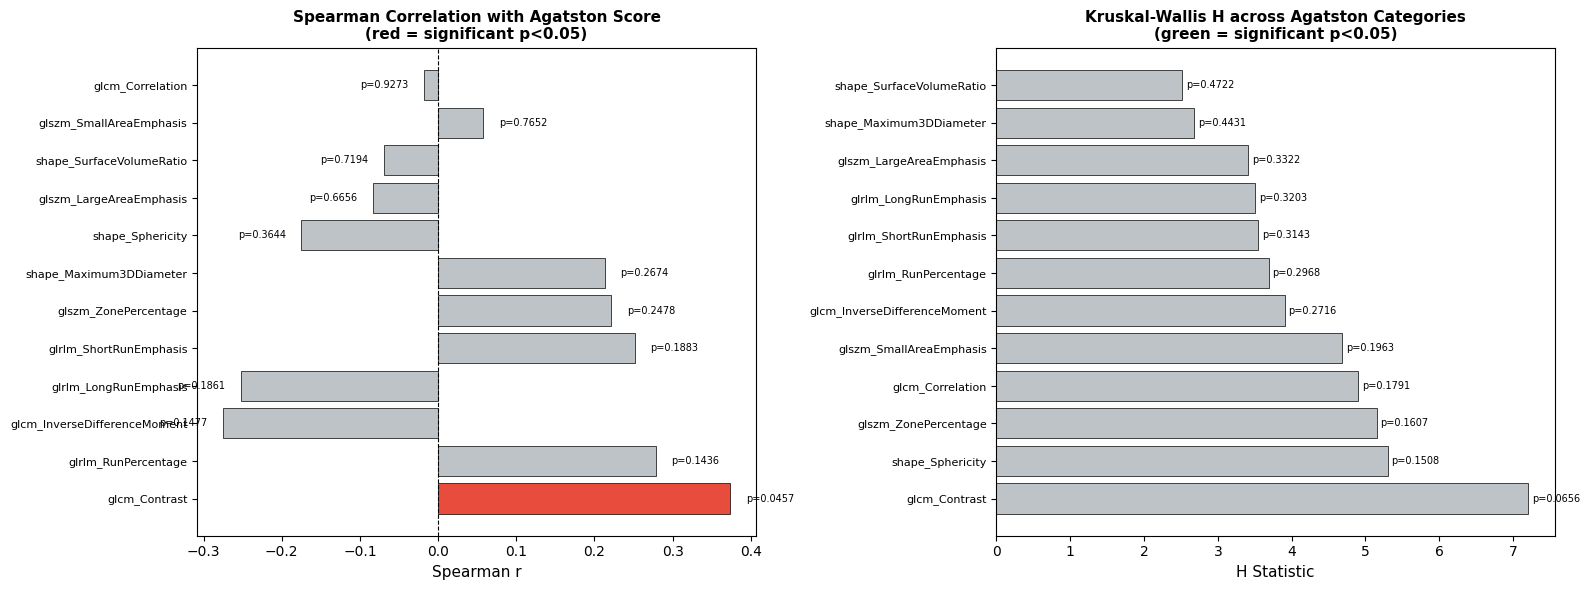

Saved: statistical_associations.png


In [13]:
# ----------------------------------------------------------------
# PLOT 2: Spearman r + KW H bar charts
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Spearman r
colors_s = ['#e74c3c' if p < 0.05 else '#bdc3c7' for p in spearman_df['p_value']]
axes[0].barh(spearman_df['Feature'], spearman_df['Spearman_r'],
             color=colors_s, edgecolor='black', linewidth=0.5)
axes[0].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Spearman r', fontsize=11)
axes[0].set_title('Spearman Correlation with Agatston Score\n(red = significant p<0.05)',
                   fontsize=11, fontweight='bold')
axes[0].tick_params(axis='y', labelsize=8)
for i, (_, row) in enumerate(spearman_df.iterrows()):
    offset = 0.02 if row['Spearman_r'] >= 0 else -0.02
    ha = 'left' if row['Spearman_r'] >= 0 else 'right'
    axes[0].text(row['Spearman_r'] + offset, i,
                 f"p={row['p_value']}", va='center', fontsize=7, ha=ha)

# Kruskal-Wallis H
colors_k = ['#2ecc71' if p < 0.05 else '#bdc3c7' for p in kw_df['p_value']]
axes[1].barh(kw_df['Feature'], kw_df['H_statistic'],
             color=colors_k, edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('H Statistic', fontsize=11)
axes[1].set_title('Kruskal-Wallis H across Agatston Categories\n(green = significant p<0.05)',
                   fontsize=11, fontweight='bold')
axes[1].tick_params(axis='y', labelsize=8)
for i, (_, row) in enumerate(kw_df.iterrows()):
    axes[1].text(row['H_statistic'] + 0.05, i,
                 f"p={row['p_value']}", va='center', fontsize=7)

plt.tight_layout()
plt.savefig('statistical_associations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: statistical_associations.png")


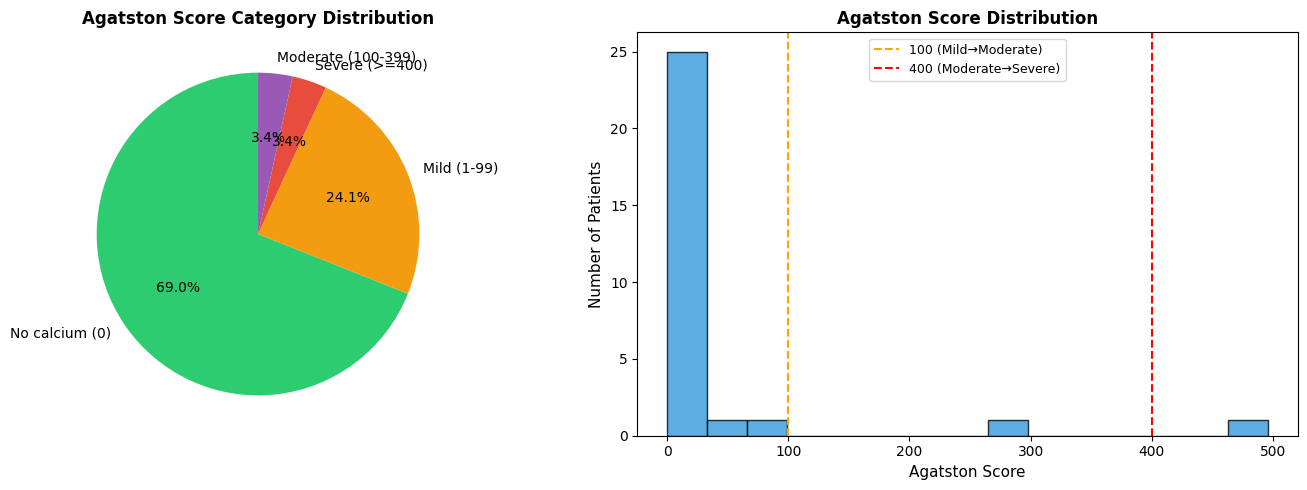

Saved: agatston_distribution.png


In [14]:
# ----------------------------------------------------------------
# PLOT 3: Agatston Distribution
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_counts = df_valid['agatston_category'].value_counts()
colors_pie = ['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']
axes[0].pie(cat_counts.values, labels=cat_counts.index,
            autopct='%1.1f%%', colors=colors_pie[:len(cat_counts)],
            startangle=90, textprops={'fontsize': 10})
axes[0].set_title('Agatston Score Category Distribution', fontsize=12, fontweight='bold')

axes[1].hist(df_valid['agatston_score'], bins=15, color='#3498db',
             edgecolor='black', alpha=0.8)
axes[1].axvline(x=100, color='orange', linestyle='--', linewidth=1.5, label='100 (Mild→Moderate)')
axes[1].axvline(x=400, color='red',    linestyle='--', linewidth=1.5, label='400 (Moderate→Severe)')
axes[1].set_xlabel('Agatston Score', fontsize=11)
axes[1].set_ylabel('Number of Patients', fontsize=11)
axes[1].set_title('Agatston Score Distribution', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig('agatston_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: agatston_distribution.png")

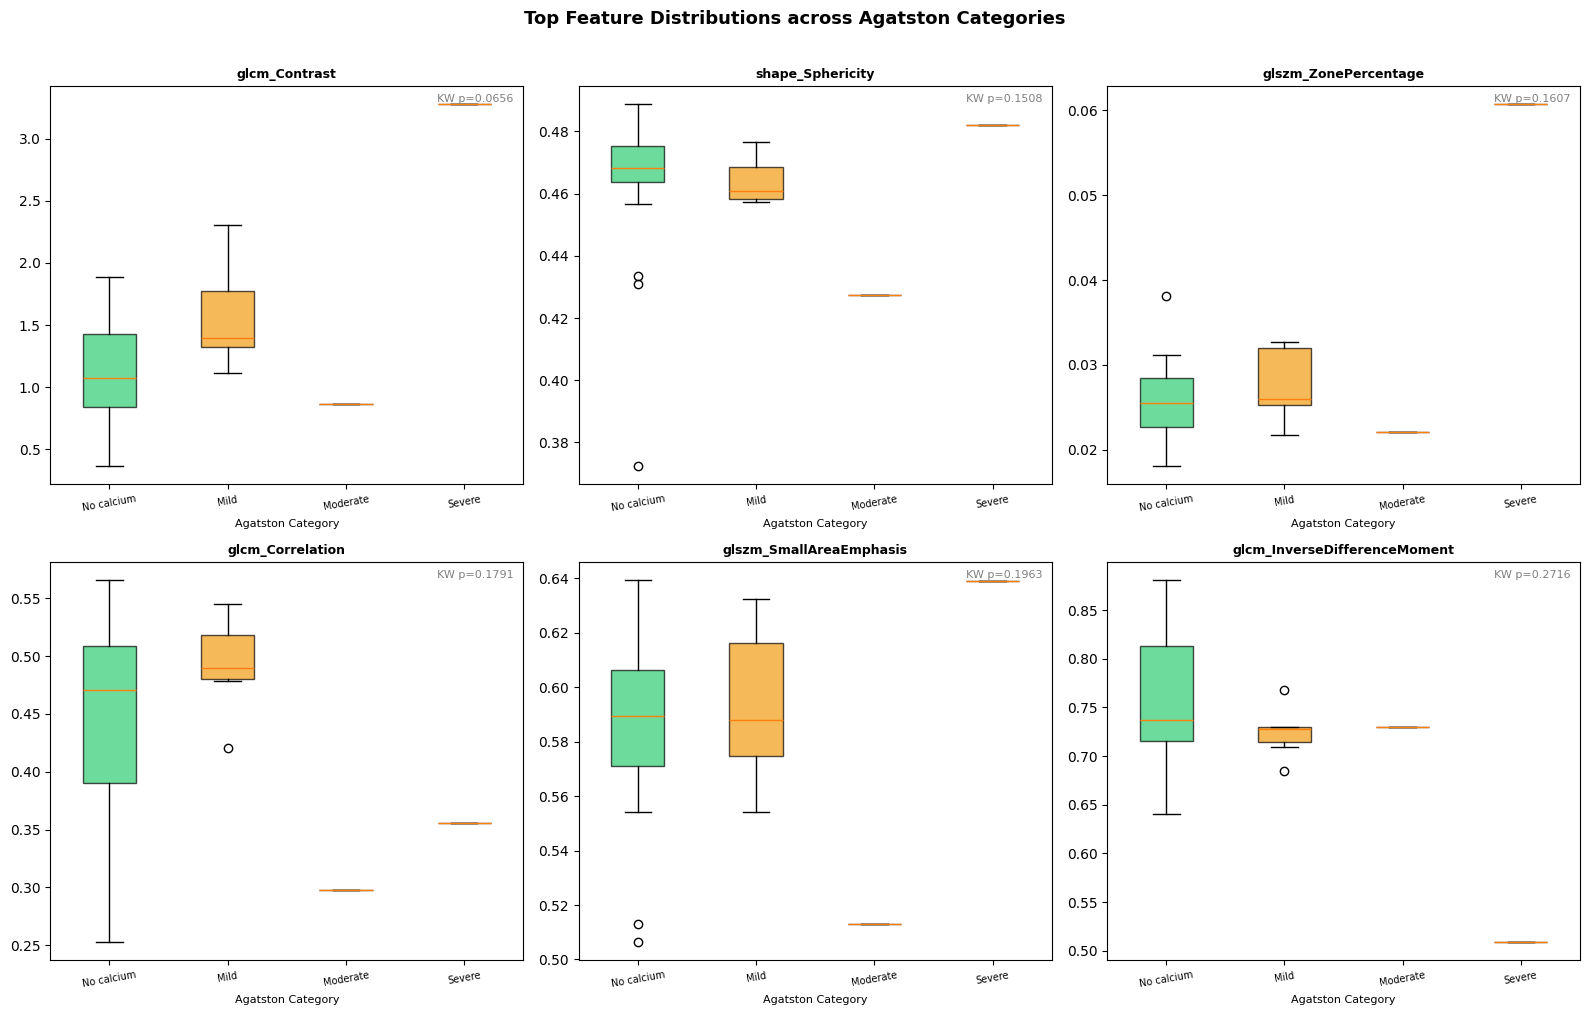

Saved: feature_boxplots.png


In [15]:
# ----------------------------------------------------------------
# PLOT 4: Feature Boxplots by Agatston Category
# ----------------------------------------------------------------
top6 = kw_df.head(6)['Feature'].tolist()
feat_map = {f.replace('original_', ''): f for f in required_features}
cat_order = ['No calcium (0)', 'Mild (1-99)', 'Moderate (100-399)', 'Severe (>=400)']
cat_order = [c for c in cat_order if c in df_valid['agatston_category'].unique()]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
box_colors = ['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']

for i, feat_short in enumerate(top6[:6]):
    feat_full = feat_map.get(feat_short)
    if feat_full is None:
        continue
    data_by_cat = [
        df_valid[df_valid['agatston_category'] == cat][feat_full].dropna().values
        for cat in cat_order
    ]
    bp = axes[i].boxplot(data_by_cat,
                         labels=[c.split('(')[0].strip() for c in cat_order],
                         patch_artist=True)
    for patch, color in zip(bp['boxes'], box_colors[:len(cat_order)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    axes[i].set_title(feat_short, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Agatston Category', fontsize=8)
    axes[i].tick_params(axis='x', labelsize=7, rotation=10)

    kw_row = kw_df[kw_df['Feature'] == feat_short]
    if not kw_row.empty:
        pval = kw_row['p_value'].values[0]
        color_txt = 'red' if pval < 0.05 else 'gray'
        axes[i].text(0.98, 0.98, f'KW p={pval}',
                     transform=axes[i].transAxes,
                     ha='right', va='top', fontsize=8, color=color_txt)

plt.suptitle('Top Feature Distributions across Agatston Categories',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_boxplots.png")


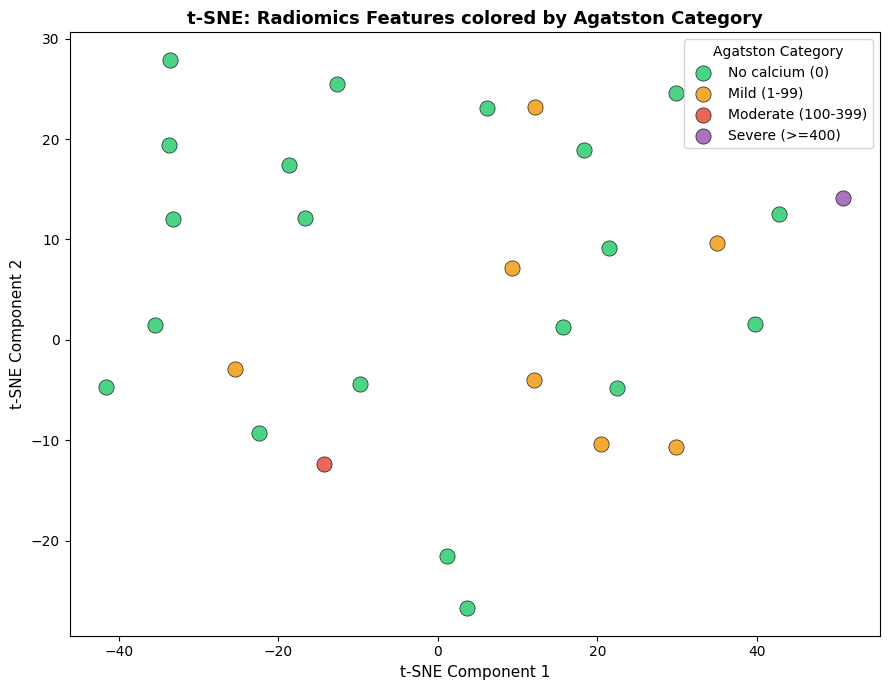

Saved: tsne_visualization.png

ALL DONE! Files saved:
  - correlation_matrix.png
  - statistical_associations.png
  - agatston_distribution.png
  - feature_boxplots.png
  - tsne_visualization.png


In [21]:
# ----------------------------------------------------------------
# PLOT 5: t-SNE
# ----------------------------------------------------------------
X = df_valid[required_features].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

perp = min(5, len(X_scaled) - 1)
tsne = TSNE(n_components=2, perplexity=perp, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

color_map = {
    'No calcium (0)':     '#2ecc71',
    'Mild (1-99)':        '#f39c12',
    'Moderate (100-399)': '#e74c3c',
    'Severe (>=400)':     '#9b59b6'
}

plt.figure(figsize=(9, 7))
for cat in cat_order:
    idx = df_valid['agatston_category'].values == cat
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1],
                label=cat, color=color_map.get(cat, 'gray'),
                s=120, edgecolors='black', linewidths=0.5, alpha=0.85)

plt.legend(title='Agatston Category', fontsize=10)
plt.title('t-SNE: Radiomics Features colored by Agatston Category',
          fontsize=13, fontweight='bold')
plt.xlabel('t-SNE Component 1', fontsize=11)
plt.ylabel('t-SNE Component 2', fontsize=11)
plt.tight_layout()
plt.savefig('tsne_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tsne_visualization.png")

print("\n" + "="*60)
print("ALL DONE! Files saved:")
print("  - correlation_matrix.png")
print("  - statistical_associations.png")
print("  - agatston_distribution.png")
print("  - feature_boxplots.png")
print("  - tsne_visualization.png")
print("="*60)
